In [2]:
#Karthick N 
#24BAD055
#importing librairies
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt

In [3]:
#Loading the dataset
df = pd.read_csv("income_random_forest.csv")
print(df.head())

   Age  EducationYears  HoursPerWeek  Experience  Income
0   37              12            44          12       0
1   46              19            58          33       1
2   53              10            54          24       0
3   46              11            22           6       0
4   36              17            56           3       1


In [4]:
# Splitting the dataset into features and target variable
X = df.drop("Income", axis=1)
y = df["Income"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [5]:
# Training and evaluating the Random Forest Classifier 
trees = [1, 5, 10, 20, 50, 100]
accuracies = []

for t in trees:
    rf = RandomForestClassifier(n_estimators=t, random_state=42)
    rf.fit(X_train, y_train)
    
    y_pred = rf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    accuracies.append(acc)
    print(f"Trees: {t}, Accuracy: {acc}")

Trees: 1, Accuracy: 0.9722222222222222
Trees: 5, Accuracy: 1.0
Trees: 10, Accuracy: 1.0
Trees: 20, Accuracy: 1.0
Trees: 50, Accuracy: 1.0
Trees: 100, Accuracy: 1.0


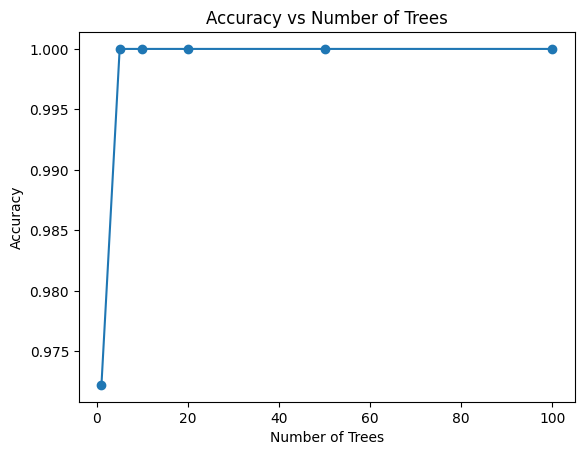

In [6]:
# Plotting the results
plt.plot(trees, accuracies, marker='o')
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Number of Trees")
plt.show()

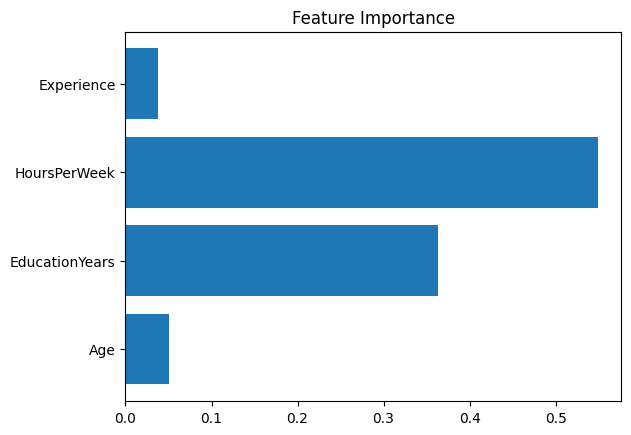

In [7]:
# Feature importance
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

importances = rf.feature_importances_
features = X.columns

plt.barh(features, importances)
plt.title("Feature Importance")
plt.show()